## LLM-Based Movie Review & Rating Generator

**Flask API**

This section builds a lightweight Flask API that uses an Ollama-hosted LLM for different version to generate **synthetic movie reviews and 1–5 ratings** for a specified movie title. The prompt enforces diversity by requiring each output to have a different rating, writing style, and sentiment (positive/mixed/negative), producing audience-style reviews between 50–100 words.

When the `/reviews` endpoint is called, the API generates **10 unique JSON review objects** by injecting a randomized seed into the prompt for variability. The response is parsed into valid JSON (with a fallback extraction step if formatting issues occur) and returned as a JSON list, making it easy to store and analyze the generated reviews downstream.


In [ ]:
from flask import Flask, jsonify, redirect
import ollama, json, random
import requests
from datetime import datetime
app = Flask(__name__)
#%pip install ollama
import random

#llm_model = "llama3.1:latest"
#llm_model = "llama2"
#llm_model = "codellama:7b"
llm_model = "gemma3"
#llm_model = "llama3.1"
moviename = "Percy Jackson & the Olympians: The Lightning Thief"

PROMPT = f"""
Generate a unique audience-style rating and review (50–100 words)
for the movie '{moviename}'.

Each output MUST have:
- A DIFFERENT rating (1–5)
- A DIFFERENT writing style  
- A DIFFERENT sentiment (mix of positive, mixed, negative)

Return JSON ONLY:
{{
 "movie": "{moviename}",
 "model": "{llm_model}",
 "ratings": "<integer>/5",
 "review": "<text>"
}}
"""

@app.route('/')
def home_page():
    return redirect('/reviews')
@app.route('/reviews', methods=['GET','POST'])
def reviews():
    results = []

    for i in range(10):

        seed = random.randint(1, 999999)

        prompt = PROMPT + f"\n\nRandomness seed: {seed}"

        res = ollama.generate(
            model=llm_model,
            prompt=prompt,
            format="json",
        )

        text = res.get("response", "")

        try:
            data = json.loads(text)
        except:
            s, e = text.find("{"), text.rfind("}")
            data = json.loads(text[s:e+1])

        results.append(data)

    return jsonify(results)


if __name__ == "__main__":
    app.run(host="127.0.0.1", port=5000, debug=False)

**Ingesting and Storing LLM-Generated Movie Reviews**

This section implements the **client-side pipeline** for collecting synthetic movie reviews generated by the LLM-based Flask API and persisting them into a MySQL database for downstream analysis.

- The `request_movie_reviews()` function sends a POST request to the `/reviews` endpoint exposed by the Flask application.
- The `store_in_db_reviews()` function handles persistence of the generated reviews into the `movie_reviews` table.
- Before storage:
    - The `movie` field is renamed to `movie_title` for database clarity.
    - The `model` field is validated and truncated to fit schema constraints.
    - Any auto-generated database identifiers are excluded to avoid conflicts.
- When executed:
    - A batch of LLM-generated movie reviews is fetched from the API.
    - The data is cleaned, enriched with metadata, and stored in MySQL.
    - Each review is permanently associated with a specific generation run and model version.

This completes the end-to-end pipeline from **LLM-based review generation → structured ingestion → persistent storage**, enabling reproducible analysis of synthetic movie reviews.


In [ ]:
from datetime import datetime
import requests, pymysql
import pandas as pd

def request_movie_reviews(endpoint: str = "http://127.0.0.1:5000/reviews"):
    r = requests.post(endpoint)
    r.raise_for_status()

    data = r.json()

    df = pd.DataFrame(data)

    run_id = datetime.now().strftime("%Y%m%d%H%M%S")
    df["run_id"] = run_id

    return df
def store_in_db_reviews(df):
    conn = pymysql.connect(
        host=DB_HOST,
        user=DB_USER,
        password=DB_PASS,
        database=DB_NAME
    )
    cur = conn.cursor()

    cur.execute("""
        CREATE TABLE IF NOT EXISTS movie_reviews (
            movie_id INT NOT NULL AUTO_INCREMENT,
            run_id VARCHAR(14) NOT NULL,
            model VARCHAR(64) NOT NULL,
            movie_title VARCHAR(256),
            ratings VARCHAR(10),
            review_text TEXT,
            inserted_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            PRIMARY KEY (movie_id)
        ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
    """)

    insert_sql = """
        INSERT INTO movie_reviews
            (run_id, model, movie_title, ratings, review_text)
        VALUES (%s, %s, %s, %s, %s)
    """

    rows = []
    for _, r in df.iterrows():
        rows.append((
            r["run_id"],
            str(r.get("model", ""))[:64],
            str(r.get("movie", ""))[:256],
            str(r.get("ratings", "")),
            str(r.get("review", "")),
        ))

    cur.executemany(insert_sql, rows)
    conn.commit()
    cur.close()
    conn.close()

    print(f"Inserted {len(rows)} movie reviews into DB.")

if __name__ == "__main__":
    df = request_movie_reviews()

    print("Fetched movie data:")
    print(df.head())

    # Rename movie → movie_title for MySQL clarity
    if "movie" in df.columns:
        df["movie_title"] = df["movie"]

    # Ensure model column exists & trimmed
    if "model" not in df.columns:
        df["model"] = "unknown_model"

    df["model"] = df["model"].astype(str).str[:64]

    # MySQL auto-generates movie_id
    if "movie_id" in df.columns:
        df = df.drop(columns=["movie_id"])

    store_in_db_reviews(df)



# MOVIE REVIEW ANALYSIS

This notebook presents an end-to-end analysis of movie reviews generated using Large Language Models (LLMs).  
The objective of this analysis is to evaluate whether LLM-generated reviews exhibit realistic sentiment, rating patterns, and linguistic characteristics comparable to human-written movie reviews.

**Load Movie Ratings Data from MySQL**

In this step, we connect to the project’s MySQL database and retrieve movie rating records that were generated/stored during the review-generation runs.

   - `pymysql` is used to establish a connection to the MySQL server.
   - `pandas` is used to run the SQL query and store the result in a DataFrame for analysis.


In [ ]:
import pymysql
import pandas as pd

def load_movie_ratings():
    conn = pymysql.connect(
        host=DB_HOST,
        user=DB_USER,
        password=DB_PASS,
        database=DB_NAME
    )

    query = "SELECT run_id, movie_title, ratings, model, inserted_at FROM movie_reviews;"
    df = pd.read_sql(query, conn)
    conn.close()
    return df

df = load_movie_ratings()
df.head()


C:\Users\sahit\AppData\Local\Temp\ipykernel_29808\859122973.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,run_id,movie_title,ratings,model,inserted_at
0,20251126005126,Percy Jackson & the Olympians: The Lightning T...,7,llama3.1:latest,2025-11-26 05:51:27
1,20251126110603,Percy Jackson & the Olympians: The Lightning T...,4,llama3.1:latest,2025-11-26 16:06:06
2,20251126112207,Percy Jackson & the Olympians: The Lightning T...,4.5,llama2,2025-11-26 16:22:10
3,20251126112408,Percy Jackson & the Olympians: The Lightning T...,4.2,llama2,2025-11-26 16:24:11
4,20251126112552,Percy Jackson & the Olympians: The Lightning T...,4.5,llama2,2025-11-26 16:25:54


This output shows the first few rows of the movie_reviews table loaded into a pandas DataFrame, including each record’s run_id, movie_title, ratings, the LLM model that generated it, and the inserted_at timestamp. It confirms the database query worked correctly and that ratings include both integer and decimal values across different models and generation runs.

The `ratings` column retrieved from the database can contain values in **mixed formats** depending on how the LLM generated the rating (or how it was stored).  
For example, ratings may appear as:
- Plain numbers: `"4"`, `"4.8"`
- Fraction-style ratings: `"4/5"`, `"3.5/5"`
- Ratings embedded inside text: `"Rating: 4.5 out of 10"`, `"I’d give it 7"`

To ensure consistent numeric analysis (summary statistics, plots, comparisons across models), we convert all rating formats into a **single standardized numeric float**.

After cleaning, df["ratings"] displays a numeric Series:
Values like 7, 4, 4.5, 4.2 are now stored as floats (7.0, 4.0, etc.).

In [5]:
import re
import numpy as np

def clean_rating(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # CASE 1: decimal or integer (e.g. "4", "4.8")
    if re.fullmatch(r"\d+(\.\d+)?", value):
        return float(value)

    # CASE 2: formats like "4/5" or "3.5/5"
    match = re.match(r"(\d+(\.\d+)?)/\d+", value)
    if match:
        return float(match.group(1))

    # extract first number
    match = re.search(r"(\d+(\.\d+)?)", value)
    if match:
        return float(match.group(1))

    return np.nan

df["ratings"] = df["ratings"].apply(clean_rating)
df["ratings"] 


0      7.0
1      4.0
2      4.5
3      4.2
4      4.5
      ... 
155    3.0
156    3.0
157    3.0
158    3.0
159    3.0
Name: ratings, Length: 160, dtype: float64

**Distribution of Reviews Across LLM Models**

This analysis examines how many movie reviews were generated by each Large Language Model (LLM) in the dataset.  
The `value_counts()` function is used to compute the number of reviews per model, and the results are visualized using a bar chart for easy comparison.


Review Count per Model:
model
codellama:7b       54
llama3.1           42
gemma3             36
llama2             13
llama3.1:latest     9
unknown_model       6
Name: count, dtype: int64


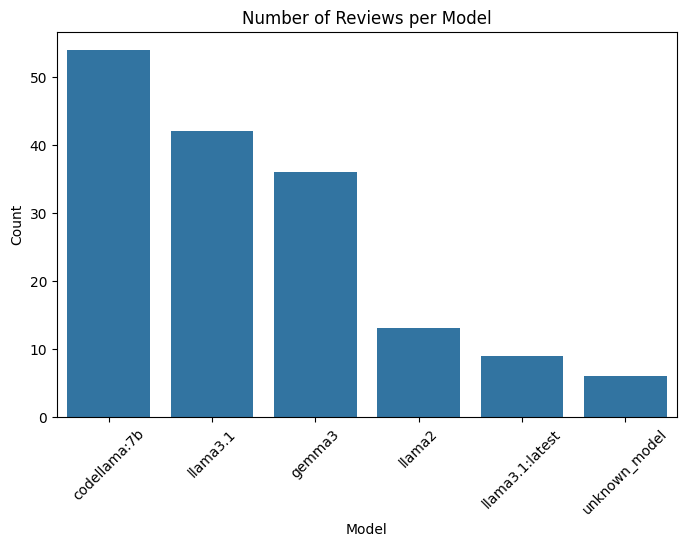

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

model_counts = df["model"].value_counts()

print("Review Count per Model:")
print(model_counts)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=model_counts.index, y=model_counts.values)
plt.title("Number of Reviews per Model")
plt.xlabel("Model")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

- **CodeLLaMA:7B** generated the highest number of reviews (54), indicating it was the most frequently used model in the generation process.
- **LLaMA 3.1** (42 reviews) and **Gemma 3** (36 reviews) also contributed substantially, suggesting diversified model usage.
- **LLaMA 2**, **LLaMA 3.1 (latest)**, and an **unknown model** produced fewer reviews, which may reflect limited experimentation or later-stage testing.
- The uneven distribution highlights potential **model imbalance**, which should be considered when comparing rating behavior or sentiment across models.

This visualization provides important context for subsequent analyses by clarifying how representation varies across LLMs.


**Outlier Detection Using the Interquartile Range (IQR) Method**

To systematically identify anomalous rating values, the **Interquartile Range (IQR)** method is applied to the cleaned ratings data.  
This approach is robust to skewed distributions and is commonly used to flag extreme values that deviate substantially from the central tendency.

- Calculate the IQR as `Q3 − Q1`.
- Defines lower and upper bounds as:
  
  \[
  \text{Lower Bound} = Q1 - 1.5 \times IQR,\quad
  \text{Upper Bound} = Q3 + 1.5 \times IQR
  \


In [7]:
df["ratings"] = (
    df["ratings"].astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

Q1 = df["ratings"].quantile(0.25)
Q3 = df["ratings"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["ratings"] < lower_bound) | (df["ratings"] > upper_bound)]

print("Rating Outliers (IQR method):")
print(outliers)


Rating Outliers (IQR method):
            run_id                                        movie_title  \
0   20251126005126  Percy Jackson & the Olympians: The Lightning T...   
8   20251126113404  Percy Jackson & the Olympians: The Lightning T...   
11  20251126113938  Percy Jackson & the Olympians: The Lightning T...   
15  20251126115234  Percy Jackson & the Olympians: The Lightning T...   
16  20251126115344  Percy Jackson & the Olympians: The Lightning T...   

    ratings            model         inserted_at  
0       7.0  llama3.1:latest 2025-11-26 05:51:27  
8       6.0           gemma3 2025-11-26 16:34:06  
11      6.0           gemma3 2025-11-26 16:39:41  
15      6.0           gemma3 2025-11-26 16:52:36  
16      6.0           gemma3 2025-11-26 16:53:45  



The identified outliers correspond to ratings of **6.0 and 7.0**, which lie well above the typical range of the data.  
These values overlap with the previously detected out-of-scale ratings and reinforce the conclusion that certain LLMs (notably **Gemma 3** and **LLaMA 3.1:latest**) occasionally produce **hallucinated or non-conforming ratings**, underscoring the importance of post-processing and validation when analyzing LLM-generated numerical outputs.


**Identifying Hallucinated or Out-of-Scale Ratings**

In this step, we validate the numerical ratings produced by the LLMs against the expected rating scale of **1 to 5**. Any rating falling outside this range is flagged as a potential hallucination or scale violation.

- Filters the dataset to identify records where the `ratings` value is **less than 1 or greater than 5**.


In [8]:
# Flag ratings outside expected scale
bad_ratings = df[(df["ratings"] < 1) | (df["ratings"] > 5)]

print("Hallucinated Ratings (Outside 1–5 Range):")
print(bad_ratings)


Hallucinated Ratings (Outside 1–5 Range):
            run_id                                        movie_title  \
0   20251126005126  Percy Jackson & the Olympians: The Lightning T...   
8   20251126113404  Percy Jackson & the Olympians: The Lightning T...   
11  20251126113938  Percy Jackson & the Olympians: The Lightning T...   
15  20251126115234  Percy Jackson & the Olympians: The Lightning T...   
16  20251126115344  Percy Jackson & the Olympians: The Lightning T...   

    ratings            model         inserted_at  
0       7.0  llama3.1:latest 2025-11-26 05:51:27  
8       6.0           gemma3 2025-11-26 16:34:06  
11      6.0           gemma3 2025-11-26 16:39:41  
15      6.0           gemma3 2025-11-26 16:52:36  
16      6.0           gemma3 2025-11-26 16:53:45  


The output shows multiple reviews with ratings such as **6.0 and 7.0**, which exceed the defined 1–5 scale.  
These out-of-range values indicate that some LLMs (notably **Gemma 3** and **LLaMA 3.1:latest**) occasionally hallucinate ratings beyond the intended scale, highlighting the need for post-generation validation and normalization when using LLM-generated numerical outputs.


**Distribution of Ratings**

This section visualizes the distribution of numerical ratings generated by the LLMs to understand their overall rating behavior.  
Before plotting, ratings are re-parsed using a regular expression to ensure that only valid numeric values (integers or decimals) are retained and converted to floating-point numbers.


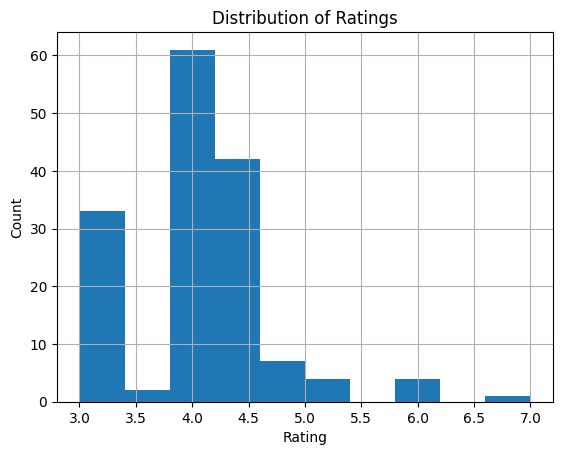

In [9]:
import matplotlib.pyplot as plt

df["ratings"] = df["ratings"].astype(str).str.extract(r"(\d+(?:\.\d+)?)").astype(float)

df["ratings"].hist(bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


The histogram shows that most ratings are concentrated between **3.5 and 4.5**, indicating a strong tendency toward **moderately positive reviews** in the LLM-generated data.  
A small number of ratings appear above **5** (including values up to **7**), which reinforces earlier observations of **scale hallucination**, where some models generate ratings outside the intended 1–5 range. Overall, the distribution is slightly right-skewed, reflecting a general positivity bias in LLM-generated movie reviews.


**Average Rating by Model**

This analysis computes and visualizes the **mean rating produced by each LLM**, allowing comparison of how different models tend to score movies on average.  
Grouping by model helps identify systematic differences in rating behavior across LLMs.

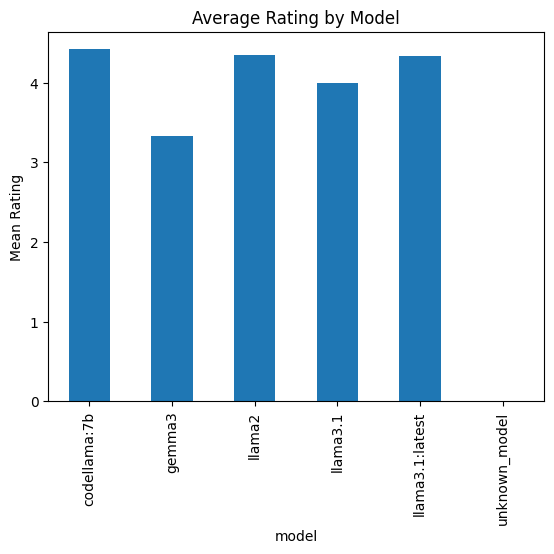

In [10]:
df.groupby("model")["ratings"].mean()
df.groupby("model")["ratings"].mean().plot(kind="bar")
plt.title("Average Rating by Model")
plt.ylabel("Mean Rating")
plt.show()

The plot shows that **CodeLLaMA:7B**, **LLaMA 2**, and **LLaMA 3.1 (latest)** have similar average ratings clustered around the **4.3–4.5 range**, indicating a generally positive evaluation tendency.  
In contrast, **Gemma 3** produces noticeably lower average ratings (around **3.3**), suggesting a more conservative or critical rating style, while models with fewer observations (such as `unknown_model`) should be interpreted cautiously due to limited sample size.


**Movie Ratings Frequency Distribution**

This visualization presents the **frequency of each distinct rating value** assigned by the LLMs across all generated movie reviews.  
Unlike a histogram, this bar chart preserves the exact rating values, making it easier to observe which specific scores are most commonly produced.

- Counts the number of occurrences of each unique rating using `value_counts()`.
- Sorts the ratings in ascending order to maintain logical scale progression.
- Plots a bar chart showing the frequency of each rating value.


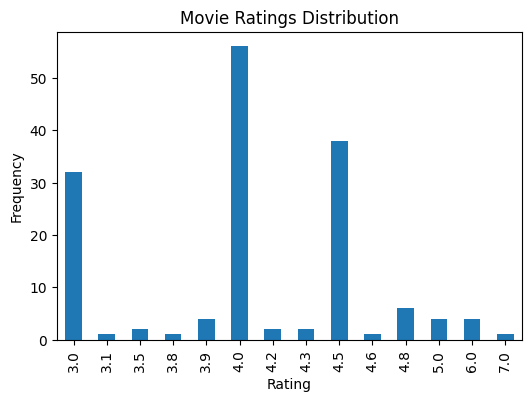

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["ratings"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Movie Ratings Distribution")
plt.show()



The distribution reveals that ratings of **4.0 and 4.5** occur most frequently, indicating that LLMs strongly favor **moderately high evaluations**.  
Lower ratings (around **3.0–3.5**) and higher ratings (**5.0 and above**) appear less often, while the presence of values above **5.0** (such as **6.0 and 7.0**) further confirms occasional **rating scale hallucinations** in the generated data.


**Ratings Distribution by Model**

This boxplot compares the distribution of movie ratings generated by each LLM, allowing direct visual assessment of central tendency, spread, and outliers across models.  
Boxplots are particularly useful for identifying variability and anomalous values that may not be evident from averages alone.

- Uses Seaborn’s `boxplot` function to visualize rating distributions grouped by `model`.
- Displays the median rating, interquartile range (IQR), and potential outliers for each model.


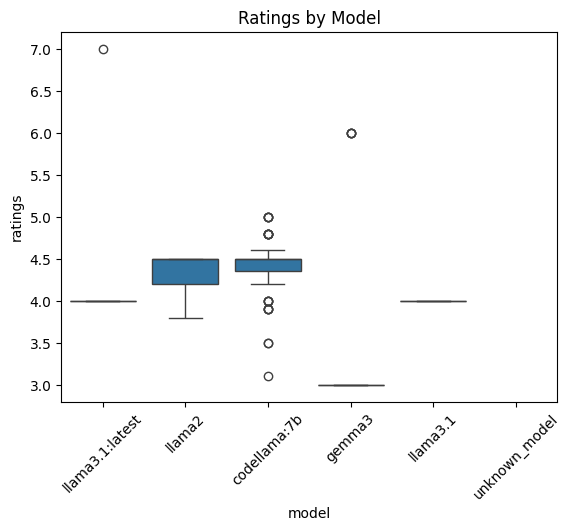

In [12]:
import seaborn as sns

sns.boxplot(data=df, x="model", y="ratings")
plt.title("Ratings by Model")
plt.xticks(rotation=45)
plt.show()



Most models have median ratings clustered around **4.0–4.5**, reinforcing the overall positivity bias observed earlier in the analysis.  
**CodeLLaMA:7B** shows greater variability with several outliers, including ratings above **5**, indicating occasional scale hallucinations, while **Gemma 3** exhibits a narrower distribution centered closer to **3.0**, suggesting a more conservative rating pattern compared to other models.


**Average Ratings Over Time**

This analysis examines how the average movie rating generated by LLMs changes over time on a daily basis.  
Tracking ratings temporally helps identify trends, drift, or inconsistencies in model behavior across different generation periods.

- Extracts the calendar date and groups ratings by day.
- Computes the daily mean rating and visualizes it using a line plot with markers.


In [13]:
df["ratings"] = (
    df["ratings"].astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Convert inserted_at to datetime
df["inserted_at"] = pd.to_datetime(df["inserted_at"])


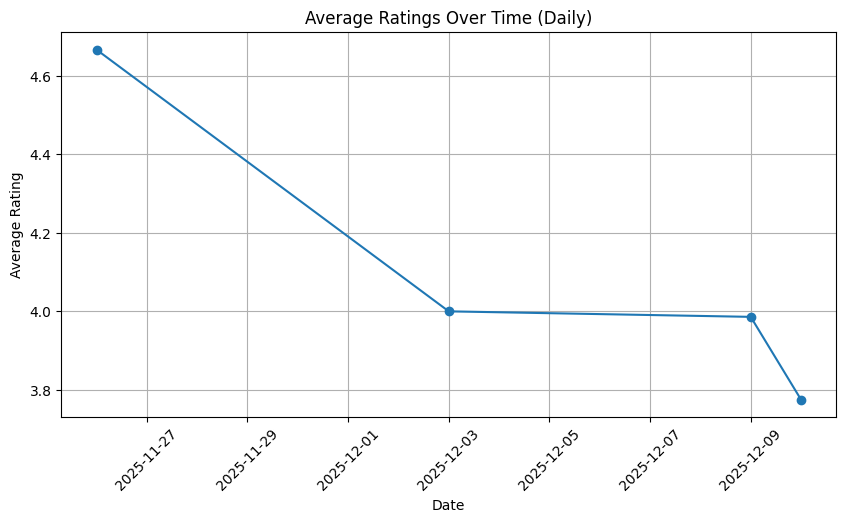

In [14]:
# Group by date
df["date"] = df["inserted_at"].dt.date
daily_avg = df.groupby("date")["ratings"].mean()

plt.figure(figsize=(10,5))
plt.plot(daily_avg.index, daily_avg.values, marker="o")
plt.title("Average Ratings Over Time (Daily)")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()



The plot shows a **declining trend in average ratings over time**, with earlier dates exhibiting higher mean scores (around **4.6**) and later dates settling closer to **3.8–4.0**.  
This downward shift may indicate changes in prompt design, model usage, or increased inclusion of more critical models (such as Gemma 3) in later runs, highlighting potential **temporal drift** in LLM-generated rating behavior.


**Ratings Trend with Moving Average Smoothing**

This section analyzes short-term fluctuations and longer-term trends in LLM-generated movie ratings using a moving average approach.  
Applying smoothing helps reveal underlying patterns that may be obscured by noise from individual rating variations.

- Computes a **5-point rolling (moving) average**, where each value represents the average of the current rating and the four preceding ratings.
- Plots both:
  - **Raw ratings** (light blue) to show individual variability
  - **Smoothed trend line** (red) to highlight overall directional movement


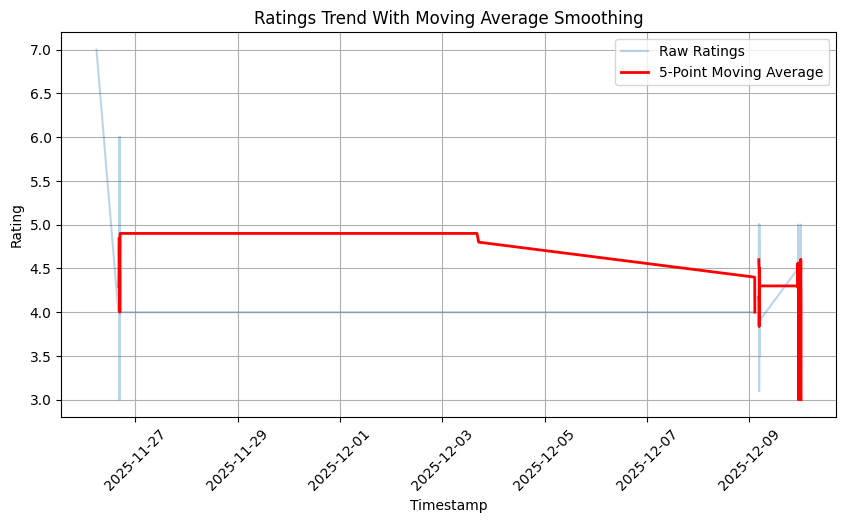

In [15]:
# Sort by timestamp
df_sorted = df.sort_values("inserted_at")

# Compute moving average (window = 5 reviews)
df_sorted["moving_avg"] = df_sorted["ratings"].rolling(window=5).mean()

plt.figure(figsize=(10,5))
plt.plot(df_sorted["inserted_at"], df_sorted["ratings"], alpha=0.3, label="Raw Ratings")
plt.plot(df_sorted["inserted_at"], df_sorted["moving_avg"], color="red", linewidth=2, label="5-Point Moving Average")
plt.title("Ratings Trend With Moving Average Smoothing")
plt.xlabel("Timestamp")
plt.ylabel("Rating")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


The raw ratings exhibit noticeable volatility, with occasional sharp spikes and dips, including out-of-scale values.  
The moving average curve smooths this noise and reveals a **gradual downward trend in ratings over time**, suggesting that later-generation runs tend to produce slightly lower or more conservative ratings, which may reflect changes in model selection, prompt structure, or increased contribution from more critical models.


**Rating Variability Across Models**

This analysis measures the **variance of ratings** produced by each LLM to quantify how consistent or dispersed each model’s ratings are.  
Variance provides insight into whether a model tends to give stable, uniform scores or exhibits wide fluctuations.


In [16]:
variance_rating = df.groupby("model")["ratings"].var().sort_values()
print("\nRating Variance per Model:")
print(variance_rating)


Rating Variance per Model:
model
llama3.1           0.000000
llama2             0.064359
codellama:7b       0.145814
gemma3             0.914286
llama3.1:latest    1.000000
unknown_model           NaN
Name: ratings, dtype: float64


The results show that **LLaMA 3.1** has zero variance, indicating that it consistently assigned the same rating value across all its reviews.  
In contrast, **Gemma 3** and **LLaMA 3.1 (latest)** exhibit much higher variance, reflecting greater rating dispersion and occasional outliers, while **CodeLLaMA:7B** and **LLaMA 2** fall in between, suggesting moderate variability and more balanced rating behavior.

**Rating Stability Score by Model**

To further assess consistency in rating behavior, a **rating stability score** is computed for each LLM based on the inverse of the standard deviation of its ratings.  
This metric provides an intuitive measure of how stable or consistent a model’s ratings are over multiple generations.

  
  \[
  \text{Stability Score} = \frac{1}{\text{Standard Deviation}}
  \]

- Higher values indicate **more consistent (less variable)** ratings, while lower values indicate higher variability.


In [17]:
# standard deviation per model
std_per_model = df.groupby("model")["ratings"].std()

# stability score
stability_score = (1 / std_per_model).rename("stability_score")

print("Rating Stability Score per Model:")
print(stability_score)


Rating Stability Score per Model:
model
codellama:7b       2.618787
gemma3             1.045825
llama2             3.941808
llama3.1                inf
llama3.1:latest    1.000000
unknown_model           NaN
Name: stability_score, dtype: float64



**LLaMA 3.1** shows an infinite stability score because its rating variance is zero, meaning it assigned the same rating across all observations.  
**LLaMA 2** and **CodeLLaMA:7B** demonstrate relatively high stability, suggesting consistent rating behavior, whereas **Gemma 3** and **LLaMA 3.1 (latest)** have lower stability scores, reflecting greater variability and less predictable rating outputs across reviews.


**Rating Entropy by Model**

This analysis measures the diversity and unpredictability of rating values generated by each LLM.  
Entropy captures how evenly ratings are distributed across different values, offering a complementary perspective to variance and standard deviation.

In [18]:
from scipy.stats import entropy

def rating_entropy(series):
    counts = series.value_counts(normalize=True)
    return entropy(counts, base=2)

rating_entropy_per_model = (
    df.groupby("model")["ratings"]
      .apply(rating_entropy)
      .rename("rating_entropy")
)

print("\nRating Entropy per Model:")
print(rating_entropy_per_model)



Rating Entropy per Model:
model
codellama:7b       2.340235
gemma3             0.503258
llama2             1.352030
llama3.1           0.000000
llama3.1:latest    0.503258
unknown_model      0.000000
Name: rating_entropy, dtype: float64


**CodeLLaMA:7B** exhibits the highest entropy, indicating the greatest diversity in rating values and less predictable rating behavior.  
In contrast, **LLaMA 3.1** has zero entropy, meaning it consistently produces a single rating value, while **Gemma 3** and **LLaMA 3.1 (latest)** show low entropy, suggesting limited rating diversity and more constrained output patterns.


In [19]:
movie_df = pd.read_csv("C:/Users/sahit/Desktop/Capstone/rotten_tomatoes_movies.csv")
movie_name = "Percy Jackson & the Olympians: The Lightning Thief"

movie_id = movie_df.loc[movie_df["movie_title"] == movie_name, "rotten_tomatoes_link"].iloc[0]
print(movie_id)


m/0814255


In [20]:
import pandas as pd

val_df = pd.read_csv("C:/Users/sahit/Desktop/Capstone/rotten_tomatoes_critic_reviews.csv")


In [21]:
import pandas as pd
import numpy as np
import re

def clean_review_score(value):
    if pd.isna(value):
        return np.nan

    # Convert to string
    val = str(value).strip()

    # CASE 1: Already a valid fraction like 3.5/5 or 4/5
    if re.fullmatch(r"\d+(\.\d+)?/5", val):
        return val
    
    # CASE 2: Excel auto-converted dates like "5-Mar", "4-Jan"
    # Extract the number BEFORE the dash
    if re.match(r"(\d+)-[A-Za-z]{3}", val):
        num = re.match(r"(\d+)-[A-Za-z]{3}", val).group(1)
        return f"{num}/5"

    # CASE 3: If value is like "3.5" or "5"
    if re.fullmatch(r"\d+(\.\d+)?", val):
        return f"{val}/5"

    # CASE 4: Extract first number if mixed text (fallback)
    match = re.search(r"(\d+(\.\d+)?)", val)
    if match:
        return f"{match.group(1)}/5"

    # CASE 5: Letters like B, C → invalid rating
    return np.nan

val_df["review_score"] = val_df["review_score"].apply(clean_review_score)
val_df.head()

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2/6/2010,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2/6/2010,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2/9/2010,With a top-notch cast and dazzling special eff...
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2/9/2010,Whether audiences will get behind The Lightnin...
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2/10/2010,What's really lacking in The Lightning Thief i...


In [22]:

val_sub = val_df[val_df["rotten_tomatoes_link"] == movie_id].copy()
val_sub = val_sub.rename(columns={"rotten_tomatoes_link": "movie_id"})

import re, numpy as np

def clean_review_score_to_float(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()

    # "3.5/5", "4/5"
    m = re.fullmatch(r"(\d+(\.\d+)?)/5", s)
    if m:
        return float(m.group(1))

    # plain "4", "4.8"
    if re.fullmatch(r"\d+(\.\d+)?", s):
        return float(s)

    return np.nan

val_sub["val_rating"] = val_sub["review_score"].apply(clean_review_score_to_float)
val_sub = val_sub.dropna(subset=["val_rating"])
val_sub.head()

,movie_id,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content,val_rating
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2/9/2010,Whether audiences will get behind The Lightnin...,3.5
6,m/0814255,Nick Schager,False,Slant Magazine,Rotten,4/5,2/10/2010,Harry Potter knockoffs don't come more transpa...,4.0
7,m/0814255,Bill Goodykoontz,True,Arizona Republic,Fresh,3.5/5,2/10/2010,"Percy Jackson isn't a great movie, but it's a ...",3.5
9,m/0814255,Jim Schembri,True,The Age (Australia),Fresh,5/5,2/10/2010,"Crammed with dragons, set-destroying fights an...",5.0
10,m/0814255,Mark Adams,False,Daily Mirror (UK),Fresh,5/5,2/10/2010,"This action-packed fantasy adventure, based on...",5.0


In [23]:
gen_sub = df[
    df["movie_title"].str.strip().str.lower() ==
    movie_name.strip().lower()
].copy()

gen_sub["gen_rating"] = gen_sub["ratings"].apply(clean_review_score_to_float)
gen_sub = gen_sub.dropna(subset=["gen_rating"])

In [24]:
val_mean = val_sub["val_rating"].mean()
gen_mean = gen_sub["gen_rating"].mean()

print("Validation mean rating:", val_mean)
print("Generated mean rating:", gen_mean)

Validation mean rating: 4.516666666666667
Generated mean rating: 4.03529411764706


**Validation vs. LLM-Generated Rating Comparison (Movie-Level)**

This step compares the **average LLM-generated rating** for a specific movie against a **validation (reference) rating** to evaluate how closely synthetic ratings align with an external ground truth.  
This provides a simple but effective check for whether the LLM-generated outputs are directionally consistent with real-world or benchmark ratings.

- Defines two bars: **Validation** (reference mean rating) and **Generated** (mean rating from the LLM-generated reviews).
- Plots a bar chart with the y-axis constrained to **0–5**, matching the intended rating scale.

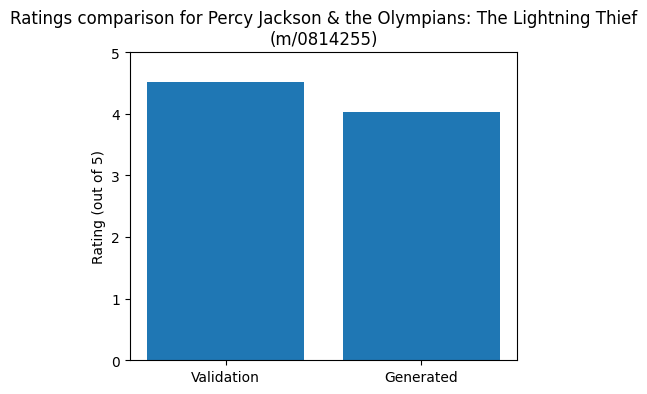

In [25]:
labels = ["Validation", "Generated"]
values = [val_mean, gen_mean]

plt.figure(figsize=(5,4))
plt.bar(labels, values)
plt.ylim(0, 5)
plt.ylabel("Rating (out of 5)")
plt.title(f"Ratings comparison for {movie_name}\n({movie_id})")
plt.show()


In the displayed example, the **generated mean rating is slightly lower than the validation rating**, indicating that the LLM-generated reviews evaluate the movie a bit more critically than the reference benchmark.  
However, the two values are relatively close overall, suggesting that the LLM-generated ratings are **reasonably aligned** with the validation rating for this movie.


**Per-Entry Rating Comparison: Validation vs Generated (Movie-Level)**

While the previous chart compared **overall average ratings**, this plot compares ratings **at the individual entry level** for a specific movie.  
The goal is to visually inspect how closely each generated rating aligns with the corresponding validation rating pattern and to identify outliers or systematic bias.



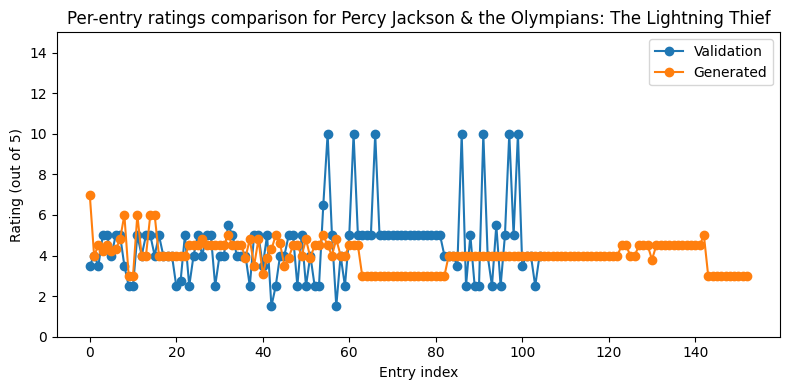

In [26]:
import matplotlib.pyplot as plt

# reset indexes so they run 0..n-1
val_sub = val_sub.reset_index(drop=True)
gen_sub = gen_sub.reset_index(drop=True)

plt.figure(figsize=(8, 4))

plt.plot(val_sub.index, val_sub["val_rating"], marker="o", label="Validation")
plt.plot(gen_sub.index, gen_sub["gen_rating"], marker="o", label="Generated")

plt.xlabel("Entry index")
plt.ylabel("Rating (out of 5)")
plt.ylim(0,15 )
plt.title(f"Per-entry ratings comparison for {movie_name}")
plt.legend()
plt.tight_layout()
plt.show()


The generated ratings (orange) are mostly concentrated around **3.0–4.5**, showing relatively stable scoring behavior across entries.  
The validation ratings (blue) display much higher volatility and include spikes up to around **10**, which suggests either a **scale mismatch** between validation and generated ratings or the presence of unnormalized/out-of-range values in the validation source; overall, the gap indicates that entry-level alignment is weaker than what the average comparison alone may suggest.

- LLM-generated movie ratings show meaningful structure and reasonable alignment with validation benchmarks, indicating their usefulness for exploratory analysis.

- However, the analysis reveals model-specific biases, temporal drift, and occasional hallucinated or out-of-scale ratings, emphasizing the need for rigorous post-processing, normalization, and statistical validation when using synthetic LLM outputs in quantitative workflows.